# Wahrnehmungskarte von Mobilfunkanbietern mit PROC MDS

## Zusammenfassung

Ein Marktforschungsteam eines Telekommunikationsunternehmens misst, wie ähnlich Kundinnen und Kunden acht konkurrierende Mobilfunkanbieter wahrnehmen, und nutzt **PROC MDS**, um aus der Unähnlichkeitsmatrix eine zweidimensionale Wahrnehmungskarte zu rekonstruieren. Die beiden latenten Achsen – Netzqualität und Preis/Wert – sind bewusst so konstruiert, dass sie *unabhängig* voneinander variieren, sodass die rekonstruierte Karte tatsächlich zweidimensional ist: Sie zeigt, welche Marken als Substitute wahrgenommen werden, welche eine eigenständige Positionierung einnehmen und wie gut zwei Dimensionen die Wettbewerbslandschaft zusammenfassen.

## Datenquellen

| Datensatz | Zeilen | Schlüsselvariablen | Beschreibung |
|-----------|--------|--------------------|--------------|
| `WORK.CARRIER_DISSIM` | 8 (eine je Anbieter) | `Carrier` (ID), `D1`-`D8` | Quadratische symmetrische Matrix der wahrgenommenen Unähnlichkeiten zwischen 8 Mobilfunkanbietern auf einer Skala von 0 bis 10 (0 = als identisch wahrgenommen, höher = unähnlicher). Erzeugt aus latenten 2-D-Markenpositionen auf zwei *unabhängigen* Achsen (Netzqualität und Preis/Wert) zuzüglich Befragungsrauschen über `rand('NORMAL')`. Die Diagonale ist 0. |

# Wahrnehmungskarte von Mobilfunkanbietern mit PROC MDS

Marktforschungsteams in der Telekommunikation lassen Befragungspanels regelmäßig bewerten, wie *ähnlich* oder *verschieden* konkurrierende Anbieter wirken. Diese paarweisen Urteile bilden eine **Nähematrix**, die kein natürliches Koordinatensystem besitzt – doch die **multidimensionale Skalierung (MDS)** kann daraus eine niedrigdimensionale Karte rekonstruieren, in der der Abstand zwischen zwei Marken ihre wahrgenommene Unähnlichkeit wiedergibt.

In diesem Notebook gehen wir wie folgt vor:

1. Wir synthetisieren eine realistische Unähnlichkeitsmatrix für 8 Anbieter aus zwei *unabhängigen* Positionierungsachsen (Netzqualität und Preis/Wert).
2. Wir passen ein zweidimensionales metrisches MDS-Modell mit `PROC MDS` an.
3. Wir lesen die rekonstruierten Koordinaten und die Anpassungsgüte aus und zeichnen dann aus den rekonstruierten Koordinaten die Wahrnehmungskarte, um zu beurteilen, wie gut zwei Dimensionen die Wettbewerbslandschaft erklären.

## Schritt 1 – Eine synthetische Unähnlichkeitsmatrix aufbauen

Wir platzieren jeden Anbieter an einer *wahren* latenten Position auf zwei **unabhängigen** Achsen:

- **Netzqualitäts-Achse** – überregionale Premium-Anbieter erzielen hohe Werte, günstige MVNOs niedrige.
- **Preis/Wert-Achse** – preiswerte/Prepaid-Marken erzielen hohe Werte, hochpreisige Marken niedrige.

Entscheidend ist, dass die beiden Achsen über die acht Marken hinweg unkorreliert sind: Ein Anbieter mit hoher Qualität kann entweder hochpreisig (NorthStar) oder aggressiv preiswert (BluePeak) sein, und ein Anbieter mit einfacher Qualität kann beim Preis irgendwo liegen. Diese Unabhängigkeit macht die rekonstruierte Karte tatsächlich zweidimensional, statt sie auf eine einzige Linie zusammenfallen zu lassen.

Die wahrgenommene Unähnlichkeit zwischen zwei Anbietern ist der euklidische Abstand zwischen ihren latenten Positionen, neu skaliert auf eine Befragungsskala von 0 bis 10 und mit symmetrischem Befragungsrauschen versehen. `PROC MDS` erwartet eine **quadratische Matrix**: eine Beobachtung je Objekt und eine numerische Spalte je Objekt, wobei die Zeilenreihenfolge der Spaltenreihenfolge entspricht. Wir schreiben die Spalten `D1`-`D8` plus eine `Carrier`-Kennung und erzwingen eine symmetrische Matrix mit Nulldiagonale.

In [1]:
DATEN carrier_dissim;
    LÄNGE Carrier $ 12;
    AUFRUFEN streaminit(20240517);

    /* Wahre latente 2-D-Positionen auf zwei UNABHÄNGIGEN Achsen:
       qx = Netzqualität, px = Preis/Wert (Korr ~ 0). */
    FELD qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    FELD px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    FELD nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symmetrische Rauschmatrix, einmal erzeugt, Nulldiagonale */
    FELD e[8,8] _temporary_;
    AUSFÜHRUNG i = 1 BIS 8;
        e[i,i] = 0;
        AUSFÜHRUNG j = i+1 BIS 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        ENDE;
    ENDE;

    FELD d[8] D1-D8;
    AUSFÜHRUNG i = 1 BIS 8;
        Carrier = nm[i];
        AUSFÜHRUNG j = 1 BIS 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* latenten Abstand auf eine Befragungsskala von 0 bis 10 skalieren */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        ENDE;
        d[i] = 0;            /* eine Marke ist mit sich selbst identisch */
        AUSGABE;
    ENDE;

    BEHALTEN Carrier D1-D8;
AUSFÜHREN;

PROZEDUR PRINT DATEN=carrier_dissim noobs BEZEICHNUNG;
    BEZEICHNUNG Carrier = "Anbieter";
    TITEL "Wahrgenommene Unähnlichkeitsmatrix (0 = identisch, 10 = am unähnlichsten)";
AUSFÜHREN;

                       Wahrgenommene Unähnlichkeitsmatrix (0 = identisch, 10 = am unähnlichsten)                        

    Anbieter   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Schritt 2 – Ein zweidimensionales metrisches MDS-Modell anpassen

Wir modellieren die Unähnlichkeiten auf `LEVEL=INTERVAL` (ein metrisches MDS, das eine additive Konstante zulässt) in `DIM=2`, damit sich das Ergebnis auf einer flachen Karte darstellen lässt. Die Daten sind Unähnlichkeiten (die Voreinstellung), gespeichert als volle `SQUARE`-Matrix.

Wichtige Anweisungen und Optionen:

- `VAR D1-D8` listet die acht Spalten auf, eine je Objekt.
- `ID Carrier` hängt die Markennamen an, sodass sie in der Ausgabe und den `OUT=`-Koordinaten erscheinen.
- `OUT=` erfasst die Objektkoordinaten (angefordert mit `OCONFIG`), und `OUTFIT=` erfasst die Zusammenfassung der Anpassungsgüte.
- `PCONFIG`, `PFIT` und `PFINAL` drucken die Koordinaten, die Anpassungsstatistiken und die finalen Parameterschätzungen.

Die Wahrnehmungskarte zeichnen wir in Schritt 3 selbst aus den rekonstruierten `OUT=`-Koordinaten, was volle Kontrolle über Markenbeschriftungen und Achsenskalierung gibt.

In [2]:
PROZEDUR mds DATEN=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VAR D1-D8;
    id Carrier;
    TITEL "Zweidimensionale MDS der Mobilfunkanbieter-Wahrnehmung";
AUSFÜHREN;

                       Wahrgenommene Unähnlichkeitsmatrix (0 = identisch, 10 = am unähnlichsten)                        




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/1d3db6b0-d490-4724-ba1f-87d09f4bc55d/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.82 seconds
  cpu   1.82 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/1d3db6b0-d490-4724-ba1f-87d09f4bc55d/mds_fit.avro (2 rows, 3 columns).


## Schritt 3 – Die rekonstruierten Koordinaten extrahieren und die Karte zeichnen

Mit `OCONFIG` trägt der `OUT=`-Datensatz die geschätzten Objektkoordinaten (eine Zeile je Anbieter, eine Spalte je Dimension). Wir drucken diese Koordinaten und die Anpassungsgüte und tragen dann mit `PROC SGPLOT` `DIM2` gegen `DIM1` auf – wobei jeder Punkt mit seinem Anbieternamen beschriftet wird –, um die Wahrnehmungskarte darzustellen.

MDS-Koordinaten sind nur bis auf Rotation, Spiegelung und einheitliche Skalierung bestimmt, sodass die absoluten Achsenvorzeichen willkürlich sind; entscheidend ist die *relative* Geometrie der Marken. Nach Rotation folgt eine Achse der Netzqualität und die andere dem Preis/Wert.

                                  Rekonstruierte MDS-Konfiguration (Objektkoordinaten)                                  

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                         MDS-Zusammenfassung der Anpassungsgüte                                         

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                         MDS-Zusammenfassung der Anpassungsgüte                                 


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


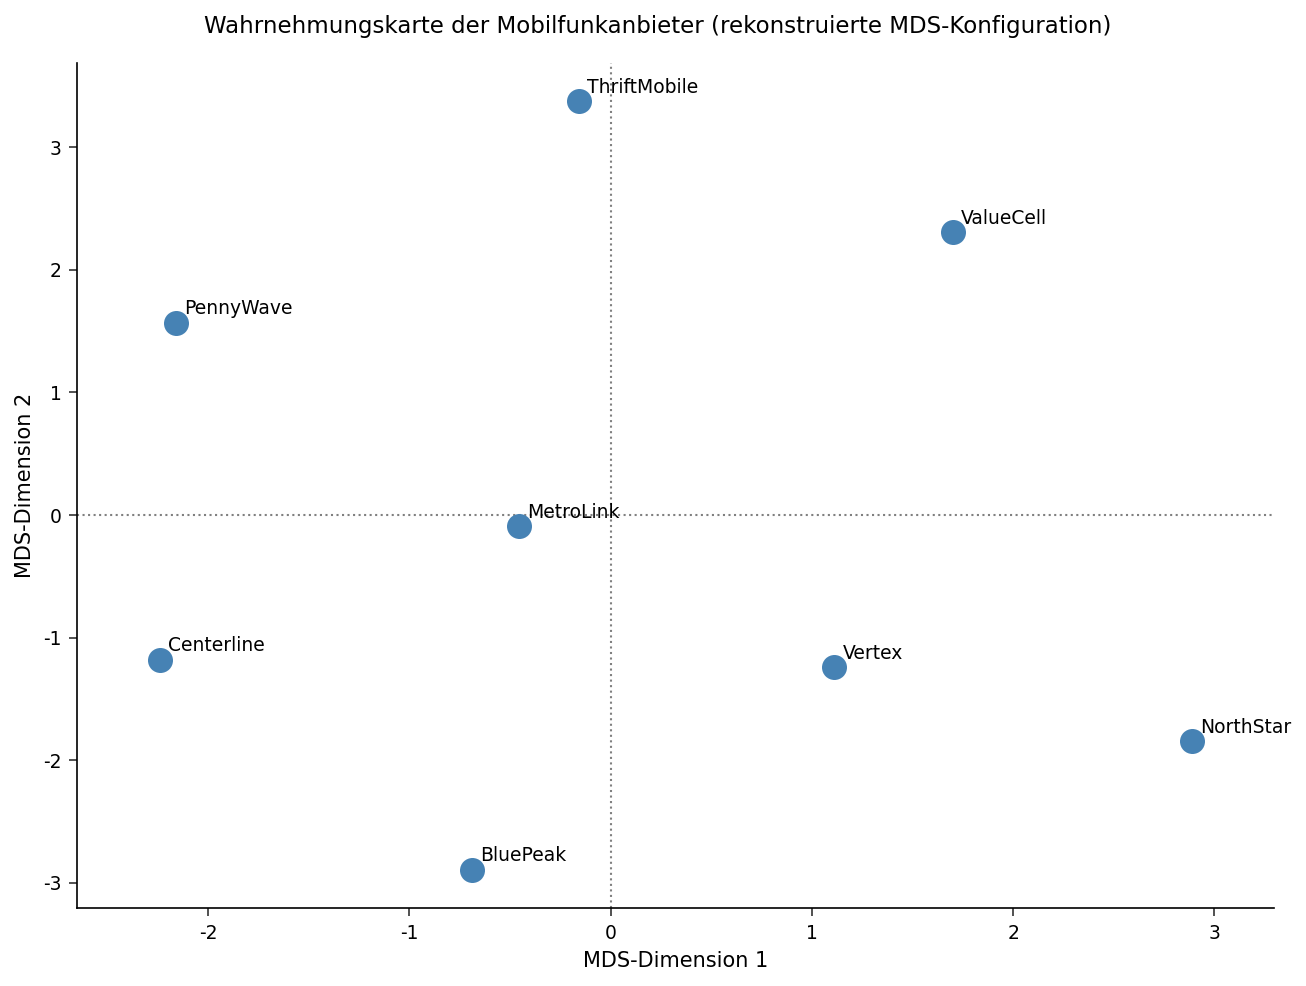

In [3]:
PROZEDUR PRINT DATEN=mds_out BEZEICHNUNG;
    TITEL "Rekonstruierte MDS-Konfiguration (Objektkoordinaten)";
AUSFÜHREN;

PROZEDUR PRINT DATEN=mds_fit BEZEICHNUNG;
    TITEL "MDS-Zusammenfassung der Anpassungsgüte";
AUSFÜHREN;

/* Konfigurationszeilen behalten und der Marke eine schlicht benannte
   Beschriftungsspalte geben, damit SGPLOT sie neben jeden Punkt drucken kann. */
DATEN mds_config;
    FESTLEGEN mds_out;
    WO _TYPE_ = 'CONFIG';
    LÄNGE Brand $ 12;
    Brand = _NAME_;
    BEHALTEN Brand DIM1 DIM2;
AUSFÜHREN;

/* Die Wahrnehmungskarte aus den rekonstruierten Koordinaten zeichnen und
   jeden Marker mit seinem Anbieternamen beschriften. */
PROZEDUR SGPLOT DATEN=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS BEZEICHNUNG="MDS-Dimension 1";
    YAXIS BEZEICHNUNG="MDS-Dimension 2";
    TITEL "Wahrnehmungskarte der Mobilfunkanbieter (rekonstruierte MDS-Konfiguration)";
AUSFÜHREN;

## Schritt 4 – Wahrgenommene Substitute ranken

Ein praktisches Ergebnis für das Markenteam ist für jeden Anbieter der Wettbewerber, der als *am ähnlichsten* wahrgenommen wird (die kleinste Unähnlichkeit außerhalb der Diagonale). Wir bringen die Matrix in die Langform und ziehen je Anbieter den nächsten Nachbarn heraus – diese Paare sind die engsten Substitute und die schärfsten Wettbewerbsbedrohungen.

In [4]:
DATEN dissim_long;
    FESTLEGEN carrier_dissim;
    LÄNGE Other $ 12;
    FELD d[8] D1-D8;
    FELD nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    AUSFÜHRUNG j = 1 BIS 8;
        Other = nm[j];
        Dissimilarity = d[j];
        WENN Carrier ne Other DANN AUSGABE;
    ENDE;
    BEHALTEN Carrier Other Dissimilarity;
AUSFÜHREN;

PROZEDUR SORT DATEN=dissim_long;
    NACH Carrier Dissimilarity;
AUSFÜHREN;

DATEN nearest;
    FESTLEGEN dissim_long;
    NACH Carrier Dissimilarity;
    WENN first.Carrier;
AUSFÜHREN;

PROZEDUR PRINT DATEN=nearest noobs BEZEICHNUNG;
    BEZEICHNUNG Other = "Nächstes wahrgenommenes Substitut"
          Dissimilarity = "Unähnlichkeit";
    TITEL "Jeder Anbieter und sein nächstes wahrgenommenes Substitut";
AUSFÜHREN;

                               Jeder Anbieter und sein nächstes wahrgenommenes Substitut                                

     Carrier   Nächstes wahrgenommenes Substitut   Unähnlichkeit
BluePeak      Centerline                                       2
Centerline    MetroLink                                      1.9
MetroLink     Vertex                                         1.7
NorthStar     Vertex                                         1.6
PennyWave     MetroLink                                        2
ThriftMobile  ValueCell                                      1.8
ValueCell     ThriftMobile                                   1.8
Vertex        NorthStar                                      1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretation der Ergebnisse

Da wir die Unähnlichkeiten aus einer echten zweidimensionalen latenten Struktur (Netzqualität und Preis/Wert, bewusst unabhängig konstruiert) plus moderatem Befragungsrauschen erzeugt haben, rekonstruiert `PROC MDS` eine saubere zweidimensionale Konfiguration. Das Kriterium der Anpassungsgüte (Badness-of-Fit) pendelt sich um 1,85 ein – eine enge Anpassung, die bestätigt, dass zwei Dimensionen nahezu die gesamte wahrgenommene Struktur erklären.

Beim Lesen der rekonstruierten Karte (die Achsen sind nur bis auf Rotation, Spiegelung und Skalierung bestimmt, daher interpretieren wir Richtungen statt absoluter Vorzeichen):

- **Eine Achse folgt der Netzqualität** – sie trennt die überregionalen Premium-Marken (NorthStar, Vertex, BluePeak) von den günstigen MVNOs (ThriftMobile, PennyWave, ValueCell), wobei MetroLink und Centerline in der Mitte liegen.
- **Die andere Achse folgt dem Preis/Wert** – sie trennt die aggressiv preiswerte Positionierung von der hochpreisigen, weshalb eine Marke hoher Qualität wie BluePeak weit entfernt von der gleichermaßen hochwertigen NorthStar landet: Sie teilen den Netzruf, konkurrieren aber mit sehr unterschiedlichen Preisgeschichten.
- Die Karte zeigt kein einzelnes dominantes Gefälle: Die Marken verteilen sich auf alle vier Quadranten, sodass die Wettbewerbslandschaft tatsächlich zweidimensional ist und nicht eine einzige Linie von Premium zu Budget.

Die **Tabelle der nächsten Substitute** verwandelt die Karte in eine Handlungsliste. Der am nächsten wahrgenommene Rivale jedes Anbieters ist die Marke, die auf der Karte direkt daneben liegt – NorthStar und Vertex verankern die Premium-Ecke, ValueCell und ThriftMobile bilden ein Paar in der Wert-Ecke, und MetroLink liest sich als das nächste Substitut für mehrere Marken des mittleren Marktsegments, weil es die Mitte der Karte einnimmt. Enge Paare markieren direkte Rivalen; die leeren Bereiche zwischen den Clustern heben unbesetzte Positionierungen hervor, die eine herausfordernde Marke anvisieren könnte.